In [ ]:
# =========================
# 1. MOUNT GOOGLE DRIVE
# =========================
from google.colab import drive
drive.mount('/content/drive')

# =========================
# 2. IMPORTS
# =========================
import os, random, shutil
import numpy as np
from PIL import Image
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report

# =========================
# 3. PATHS (FIXED FOR YOUR DRIVE)
# =========================
ROOT_DIR = "/content/drive/MyDrive/Data Set /Dataset"   # ONLY potato/tomato/apple
WORK_DIR = "/content/processed_data"

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 20
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# =========================
# 4. VERIFY DATASET
# =========================
print("Crops found:", os.listdir(ROOT_DIR))

# =========================
# 5. FIND CLASS (LEAF) DIRECTORIES
# =========================
def get_class_dirs(root):
    class_dirs = []
    for r, d, f in os.walk(root):
        imgs = [x for x in f if x.lower().endswith(('.jpg','.jpeg','.png'))]
        if imgs:
            class_dirs.append(r)
    return class_dirs

class_dirs = get_class_dirs(ROOT_DIR)
print("Total disease classes found:", len(class_dirs))

# =========================
# 6. REMOVE CORRUPTED IMAGES (SAFE)
# =========================
def clean_images(class_dirs):
    removed = 0
    for d in class_dirs:
        for f in os.listdir(d):
            p = os.path.join(d, f)
            if not os.path.isfile(p):
                continue
            try:
                Image.open(p).verify()
            except:
                os.remove(p)
                removed += 1
    print("Corrupted images removed:", removed)

clean_images(class_dirs)

# =========================
# 7. CREATE 80 / 10 / 10 SPLIT
# =========================
if os.path.exists(WORK_DIR):
    shutil.rmtree(WORK_DIR)

for split in ["train", "val", "test"]:
    os.makedirs(os.path.join(WORK_DIR, split))

for cls_dir in class_dirs:
    class_name = cls_dir.replace(ROOT_DIR, "").strip("/").replace("/", "_")

    images = [f for f in os.listdir(cls_dir)
              if f.lower().endswith(('.jpg','.jpeg','.png'))]

    random.shuffle(images)
    n = len(images)
    t1 = int(0.8 * n)
    t2 = int(0.9 * n)

    split_map = {
        "train": images[:t1],
        "val": images[t1:t2],
        "test": images[t2:]
    }

    for split, files in split_map.items():
        out_dir = os.path.join(WORK_DIR, split, class_name)
        os.makedirs(out_dir, exist_ok=True)
        for f in files:
            shutil.copy(
                os.path.join(cls_dir, f),
                os.path.join(out_dir, f)
            )

print("Dataset split completed (80/10/10)")

# =========================
# 8. DATA GENERATORS (FIXED)
# =========================
datagen = tf.keras.preprocessing.image.ImageDataGenerator(rescale=1./255)

train_gen = datagen.flow_from_directory(
    directory=WORK_DIR + "/train",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=True
)

val_gen = datagen.flow_from_directory(
    directory=WORK_DIR + "/val",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

test_gen = datagen.flow_from_directory(
    directory=WORK_DIR + "/test",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

# =========================
# 9. MODEL (MOBILENETV2)
# =========================
base_model = MobileNetV2(
    input_shape=(224,224,3),
    include_top=False,
    weights="imagenet"
)
base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(train_gen.num_classes, activation="softmax")
])

model.compile(
    optimizer=Adam(1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

# =========================
# 10. TRAIN
# =========================
model.fit(
    train_gen,
    epochs=EPOCHS,
    validation_data=val_gen
)

# =========================
# 11. TEST + REPORT
# =========================
model.evaluate(test_gen)

y_true = test_gen.classes
y_pred = np.argmax(model.predict(test_gen), axis=1)

print(classification_report(
    y_true,
    y_pred,
    target_names=list(train_gen.class_indices.keys())
))

# =========================
# 12. SAVE MODEL
# =========================
model.save("/content/drive/MyDrive/multicrop_disease_model.h5")
print("Model saved successfully")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Crops found: ['tomato', 'potato', 'apple']
Total disease classes found: 11
Corrupted images removed: 0
Dataset split completed (80/10/10)
Found 7375 images belonging to 11 classes.
Found 920 images belonging to 11 classes.
Found 927 images belonging to 11 classes.
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 11)             │         2,827 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,588,747 (9.88 MB)

 Trainable params: 330,763 (1.26 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

Epoch 1/20
231/231 ━━━━━━━━━━━━━━━━━━━━ 375s 2s/step - accuracy: 0.3831 - loss: 1.9607 - val_accuracy: 0.8402 - val_loss: 0.5830
Epoch 2/20
231/231 ━━━━━━━━━━━━━━━━━━━━ 371s 2s/step - accuracy: 0.8066 - loss: 0.6469 - val_accuracy: 0.9120 - val_loss: 0.3427
Epoch 3/20
231/231 ━━━━━━━━━━━━━━━━━━━━ 360s 2s/step - accuracy: 0.8731 - loss: 0.4152 - val_accuracy: 0.9326 - val_loss: 0.2515
Epoch 4/20
231/231 ━━━━━━━━━━━━━━━━━━━━ 374s 2s/step - accuracy: 0.9014 - loss: 0.3106 - val_accuracy: 0.9435 - val_loss: 0.2049
Epoch 5/20
231/231 ━━━━━━━━━━━━━━━━━━━━ 374s 2s/step - accuracy: 0.9231 - loss: 0.2528 - val_accuracy: 0.9478 - val_loss: 0.1797
Epoch 6/20
231/231 ━━━━━━━━━━━━━━━━━━━━ 364s 2s/step - accuracy: 0.9366 - loss: 0.2100 - val_accuracy: 0.9641 - val_loss: 0.1569
Epoch 7/20
231/231 ━━━━━━━━━━━━━━━━━━━━ 364s 2s/step - accuracy: 0.9446 - loss: 0.1831 - val_accuracy: 0.9576 - val_loss: 0.1467
Epoch 8/20
231/231 ━━━━━━━━━━━━━━━━━━━━ 364s 2s/step - accuracy: 0.9537 - loss: 0.1610 - val_accu

                                     precision    recall  f1-score   support

           apple_Apple___Apple_scab       0.97      0.95      0.96        61
            apple_Apple___Black_rot       1.00      1.00      1.00        63
     apple_Apple___Cedar_apple_rust       0.97      1.00      0.98        28
              apple_Apple___healthy       0.98      0.99      0.98       165
       potato_Potato___Early_blight       0.97      0.99      0.98       100
        potato_Potato___Late_blight       0.95      0.95      0.95       100
            potato_Potato___healthy       0.93      0.81      0.87        16
       tomato_Tomato___Early_blight       0.96      0.90      0.93       100
          tomato_Tomato___Leaf_Mold       0.92      0.98      0.95        96
tomato_Tomato___Tomato_mosaic_virus       1.00      0.95      0.97        38
            tomato_Tomato___healthy       0.99      1.00      1.00       160

                           accuracy                           0.97       9

29/29 ━━━━━━━━━━━━━━━━━━━━ 45s 1s/step


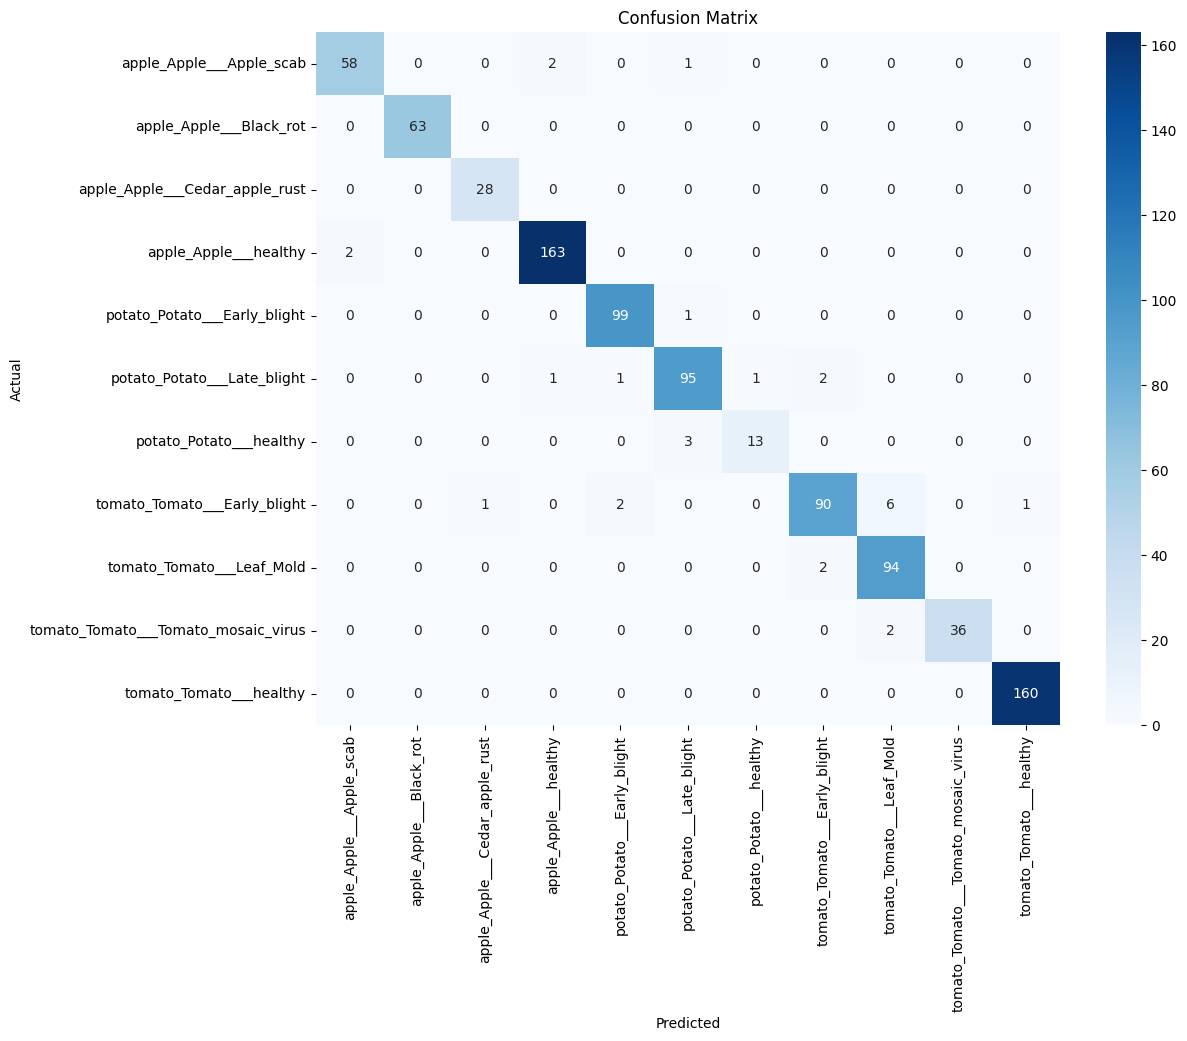

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

y_true = test_gen.classes
y_pred = np.argmax(model.predict(test_gen), axis=1)

cm = confusion_matrix(y_true, y_pred)
class_names = list(train_gen.class_indices.keys())

plt.figure(figsize=(12, 9))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=class_names,
            yticklabels=class_names,
            cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


Saving image.png to image.png
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


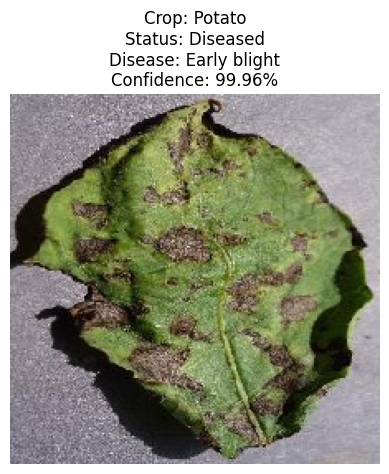

🌱 Crop Type     : Potato
🩺 Health Status : Diseased
🦠 Disease       : Early blight
📊 Confidence    : 99.96%


In [ ]:
# ===== UPLOAD PNG IMAGE FROM LAPTOP & TEST =====
from google.colab import files
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

# -------- CONFIDENCE THRESHOLD --------
CONF_THRESHOLD = 0.70   # 70%

# Upload image (PNG or JPG)
uploaded = files.upload()
img_path = list(uploaded.keys())[0]

# Load & preprocess image
img = image.load_img(img_path, target_size=(224,224))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = tf.keras.applications.mobilenet_v2.preprocess_input(img_array)

# Predict
pred = model.predict(img_array)
confidence = np.max(pred)
pred_index = np.argmax(pred)

# Class names
class_names = list(train_gen.class_indices.keys())
predicted_class = class_names[pred_index]

plt.imshow(img)
plt.axis("off")

# -------- DECISION LOGIC --------
if confidence < CONF_THRESHOLD:
    # Out-of-distribution image
    plt.title(
        "Result: Unknown Plant\n"
        "The image does not belong to apple, potato, or tomato",
        fontsize=12
    )
    plt.show()

    print("❌ Result           : Unknown Plant")
    print("ℹ️ Explanation      : Image does not match apple, potato, or tomato leaf patterns")
    print("📊 Confidence       :", f"{confidence*100:.2f}%")

else:
    # In-distribution image
    crop = predicted_class.split("_")[0]
    disease_part = predicted_class.split("___")[1]

    if disease_part.lower() == "healthy":
        status = "Healthy"
        disease = "None"
    else:
        status = "Diseased"
        disease = disease_part.replace("_", " ")

    plt.title(
        f"Crop: {crop.capitalize()}\n"
        f"Status: {status}\n"
        f"Disease: {disease}\n"
        f"Confidence: {confidence*100:.2f}%",
        fontsize=12
    )
    plt.show()

    print("🌱 Crop Type     :", crop.capitalize())
    print("🩺 Health Status :", status)
    print("🦠 Disease       :", disease)
    print("📊 Confidence    :", f"{confidence*100:.2f}%")


Saving image (1).png to image (1).png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step


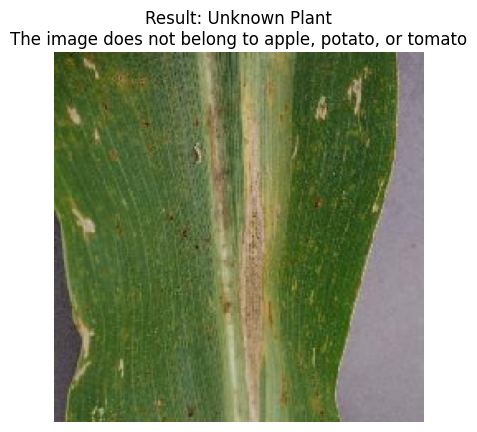

❌ Result           : Unknown Plant
ℹ️ Explanation      : Image does not match apple, potato, or tomato leaf patterns
📊 Confidence       : 58.64%


In [ ]:
# ===== UPLOAD PNG IMAGE FROM LAPTOP & TEST =====
from google.colab import files
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

# -------- CONFIDENCE THRESHOLD --------
CONF_THRESHOLD = 0.70   # 70%

# Upload image (PNG or JPG)
uploaded = files.upload()
img_path = list(uploaded.keys())[0]

# Load & preprocess image
img = image.load_img(img_path, target_size=(224,224))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = tf.keras.applications.mobilenet_v2.preprocess_input(img_array)

# Predict
pred = model.predict(img_array)
confidence = np.max(pred)
pred_index = np.argmax(pred)

# Class names
class_names = list(train_gen.class_indices.keys())
predicted_class = class_names[pred_index]

plt.imshow(img)
plt.axis("off")

# -------- DECISION LOGIC --------
if confidence < CONF_THRESHOLD:
    # Out-of-distribution image
    plt.title(
        "Result: Unknown Plant\n"
        "The image does not belong to apple, potato, or tomato",
        fontsize=12
    )
    plt.show()

    print("❌ Result           : Unknown Plant")
    print("ℹ️ Explanation      : Image does not match apple, potato, or tomato leaf patterns")
    print("📊 Confidence       :", f"{confidence*100:.2f}%")

else:
    # In-distribution image
    crop = predicted_class.split("_")[0]
    disease_part = predicted_class.split("___")[1]

    if disease_part.lower() == "healthy":
        status = "Healthy"
        disease = "None"
    else:
        status = "Diseased"
        disease = disease_part.replace("_", " ")

    plt.title(
        f"Crop: {crop.capitalize()}\n"
        f"Status: {status}\n"
        f"Disease: {disease}\n"
        f"Confidence: {confidence*100:.2f}%",
        fontsize=12
    )
    plt.show()

    print("🌱 Crop Type     :", crop.capitalize())
    print("🩺 Health Status :", status)
    print("🦠 Disease       :", disease)
    print("📊 Confidence    :", f"{confidence*100:.2f}%")


Saving potato_healthy.png to potato_healthy.png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step


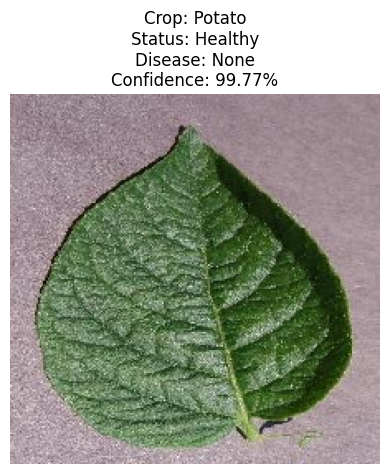

🌱 Crop Type     : Potato
🩺 Health Status : Healthy
🦠 Disease       : None
📊 Confidence    : 99.77%


In [ ]:
# ===== UPLOAD PNG IMAGE FROM LAPTOP & TEST =====
from google.colab import files
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

# -------- CONFIDENCE THRESHOLD --------
CONF_THRESHOLD = 0.70   # 70%

# Upload image (PNG or JPG)
uploaded = files.upload()
img_path = list(uploaded.keys())[0]

# Load & preprocess image
img = image.load_img(img_path, target_size=(224,224))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = tf.keras.applications.mobilenet_v2.preprocess_input(img_array)

# Predict
pred = model.predict(img_array)
confidence = np.max(pred)
pred_index = np.argmax(pred)

# Class names
class_names = list(train_gen.class_indices.keys())
predicted_class = class_names[pred_index]

plt.imshow(img)
plt.axis("off")

# -------- DECISION LOGIC --------
if confidence < CONF_THRESHOLD:
    # Out-of-distribution image
    plt.title(
        "Result: Unknown Plant\n"
        "The image does not belong to apple, potato, or tomato",
        fontsize=12
    )
    plt.show()

    print("❌ Result           : Unknown Plant")
    print("ℹ️ Explanation      : Image does not match apple, potato, or tomato leaf patterns")
    print("📊 Confidence       :", f"{confidence*100:.2f}%")

else:
    # In-distribution image
    crop = predicted_class.split("_")[0]
    disease_part = predicted_class.split("___")[1]

    if disease_part.lower() == "healthy":
        status = "Healthy"
        disease = "None"
    else:
        status = "Diseased"
        disease = disease_part.replace("_", " ")

    plt.title(
        f"Crop: {crop.capitalize()}\n"
        f"Status: {status}\n"
        f"Disease: {disease}\n"
        f"Confidence: {confidence*100:.2f}%",
        fontsize=12
    )
    plt.show()

    print("🌱 Crop Type     :", crop.capitalize())
    print("🩺 Health Status :", status)
    print("🦠 Disease       :", disease)
    print("📊 Confidence    :", f"{confidence*100:.2f}%")


Saving tomato_leaf_mold.png to tomato_leaf_mold.png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step


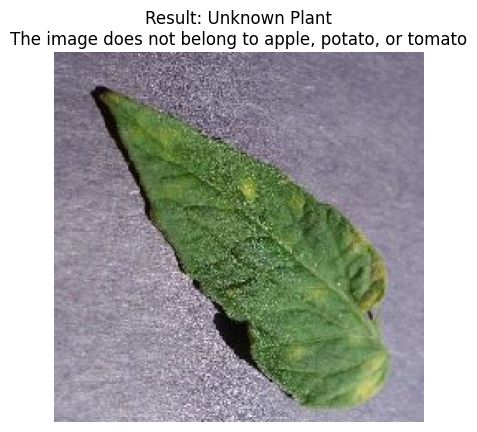

❌ Result           : Unknown Plant
ℹ️ Explanation      : Image does not match apple, potato, or tomato leaf patterns
📊 Confidence       : 66.51%


In [ ]:
# ===== UPLOAD PNG IMAGE FROM LAPTOP & TEST =====
from google.colab import files
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

# -------- CONFIDENCE THRESHOLD --------
CONF_THRESHOLD = 0.70   # 70%

# Upload image (PNG or JPG)
uploaded = files.upload()
img_path = list(uploaded.keys())[0]

# Load & preprocess image
img = image.load_img(img_path, target_size=(224,224))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = tf.keras.applications.mobilenet_v2.preprocess_input(img_array)

# Predict
pred = model.predict(img_array)
confidence = np.max(pred)
pred_index = np.argmax(pred)

# Class names
class_names = list(train_gen.class_indices.keys())
predicted_class = class_names[pred_index]

plt.imshow(img)
plt.axis("off")

# -------- DECISION LOGIC --------
if confidence < CONF_THRESHOLD:
    # Out-of-distribution image
    plt.title(
        "Result: Unknown Plant\n"
        "The image does not belong to apple, potato, or tomato",
        fontsize=12
    )
    plt.show()

    print("❌ Result           : Unknown Plant")
    print("ℹ️ Explanation      : Image does not match apple, potato, or tomato leaf patterns")
    print("📊 Confidence       :", f"{confidence*100:.2f}%")

else:
    # In-distribution image
    crop = predicted_class.split("_")[0]
    disease_part = predicted_class.split("___")[1]

    if disease_part.lower() == "healthy":
        status = "Healthy"
        disease = "None"
    else:
        status = "Diseased"
        disease = disease_part.replace("_", " ")

    plt.title(
        f"Crop: {crop.capitalize()}\n"
        f"Status: {status}\n"
        f"Disease: {disease}\n"
        f"Confidence: {confidence*100:.2f}%",
        fontsize=12
    )
    plt.show()

    print("🌱 Crop Type     :", crop.capitalize())
    print("🩺 Health Status :", status)
    print("🦠 Disease       :", disease)
    print("📊 Confidence    :", f"{confidence*100:.2f}%")


Saving apple_scab.png to apple_scab.png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step


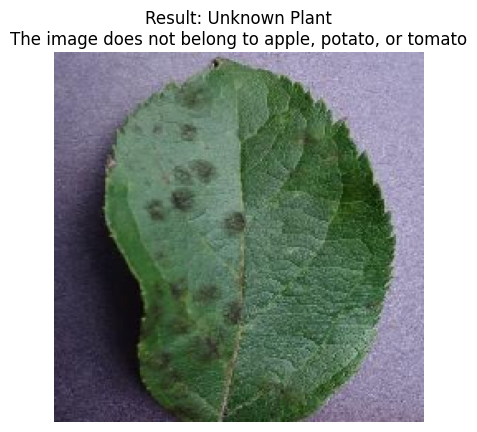

❌ Result           : Unknown Plant
ℹ️ Explanation      : Image does not match apple, potato, or tomato leaf patterns
📊 Confidence       : 50.91%


In [ ]:
# ===== UPLOAD PNG IMAGE FROM LAPTOP & TEST =====
from google.colab import files
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

# -------- CONFIDENCE THRESHOLD --------
CONF_THRESHOLD = 0.70   # 70%

# Upload image (PNG or JPG)
uploaded = files.upload()
img_path = list(uploaded.keys())[0]

# Load & preprocess image
img = image.load_img(img_path, target_size=(224,224))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = tf.keras.applications.mobilenet_v2.preprocess_input(img_array)

# Predict
pred = model.predict(img_array)
confidence = np.max(pred)
pred_index = np.argmax(pred)

# Class names
class_names = list(train_gen.class_indices.keys())
predicted_class = class_names[pred_index]

plt.imshow(img)
plt.axis("off")

# -------- DECISION LOGIC --------
if confidence < CONF_THRESHOLD:
    # Out-of-distribution image
    plt.title(
        "Result: Unknown Plant\n"
        "The image does not belong to apple, potato, or tomato",
        fontsize=12
    )
    plt.show()

    print("❌ Result           : Unknown Plant")
    print("ℹ️ Explanation      : Image does not match apple, potato, or tomato leaf patterns")
    print("📊 Confidence       :", f"{confidence*100:.2f}%")

else:
    # In-distribution image
    crop = predicted_class.split("_")[0]
    disease_part = predicted_class.split("___")[1]

    if disease_part.lower() == "healthy":
        status = "Healthy"
        disease = "None"
    else:
        status = "Diseased"
        disease = disease_part.replace("_", " ")

    plt.title(
        f"Crop: {crop.capitalize()}\n"
        f"Status: {status}\n"
        f"Disease: {disease}\n"
        f"Confidence: {confidence*100:.2f}%",
        fontsize=12
    )
    plt.show()

    print("🌱 Crop Type     :", crop.capitalize())
    print("🩺 Health Status :", status)
    print("🦠 Disease       :", disease)
    print("📊 Confidence    :", f"{confidence*100:.2f}%")
